In [ ]:
!nvidia-smi
print("✅ If you see GPU info above, you're ready!")

Tue Nov  4 06:11:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics -q
print("✅ YOLOv8 installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.1 MB/s eta 0:00:00
✅ YOLOv8 installed!


In [ ]:
# Extract dataset
!unzip -q /content/OCRFYP.v1i.yolov8.zip
print("✅ Dataset extracted!")

# Verify
!ls -lh /content/OCRFYP.v1i.yolov8
print("\n📊 Dataset info:")
!echo "Train: $(ls OCRFYP.v1i.yolov8/train/images | wc -l) images"
!echo "Valid: $(ls OCRFYP.v1i.yolov8/valid/images | wc -l) images"
!echo "Test:  $(ls OCRFYP.v1i.yolov8/test/images | wc -l) images"


✅ Dataset extracted!
total 28K
-rw-r--r-- 1 root root  418 Nov  4 06:06 data_fixed.yaml
-rw-r--r-- 1 root root  265 Nov  3 22:01 data.yaml
-rw-r--r-- 1 root root  135 Nov  3 22:01 README.dataset.txt
-rw-r--r-- 1 root root 1.2K Nov  3 22:01 README.roboflow.txt
drwxr-xr-x 4 root root 4.0K Nov  4 06:02 test
drwxr-xr-x 4 root root 4.0K Nov  4 06:02 train
drwxr-xr-x 4 root root 4.0K Nov  4 06:02 valid

📊 Dataset info:
Train: 992 images
Valid: 91 images
Test:  47 images


In [ ]:
# Create fixed data.yaml
data_yaml = """path: /content/OCRFYP.v1i.yolov8
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['Serial Plate']
"""

with open('/content/OCRFYP.v1i.yolov8/data.yaml', 'w') as f:
    f.write(data_yaml)

print("✅ Config updated!")
!cat /content/OCRFYP.v1i.yolov8/data.yaml


✅ Config updated!
path: /content/OCRFYP.v1i.yolov8
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['Serial Plate']


In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano (fast & accurate for 1 class)
model = YOLO('yolov8n.pt')

# Train
results = model.train(
    data='/content/OCRFYP.v1i.yolov8/data.yaml',
    epochs=100,
    batch=16,
    imgsz=640,
    device=0,
    patience=20,
    save=True,
    project='/content/runs',
    name='serial_plate',
    exist_ok=True,
    plots=True,
    cache=False,
    verbose=True
)

print("\n✅ Training complete!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.224 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/OCRFYP.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

📈 Training Results:


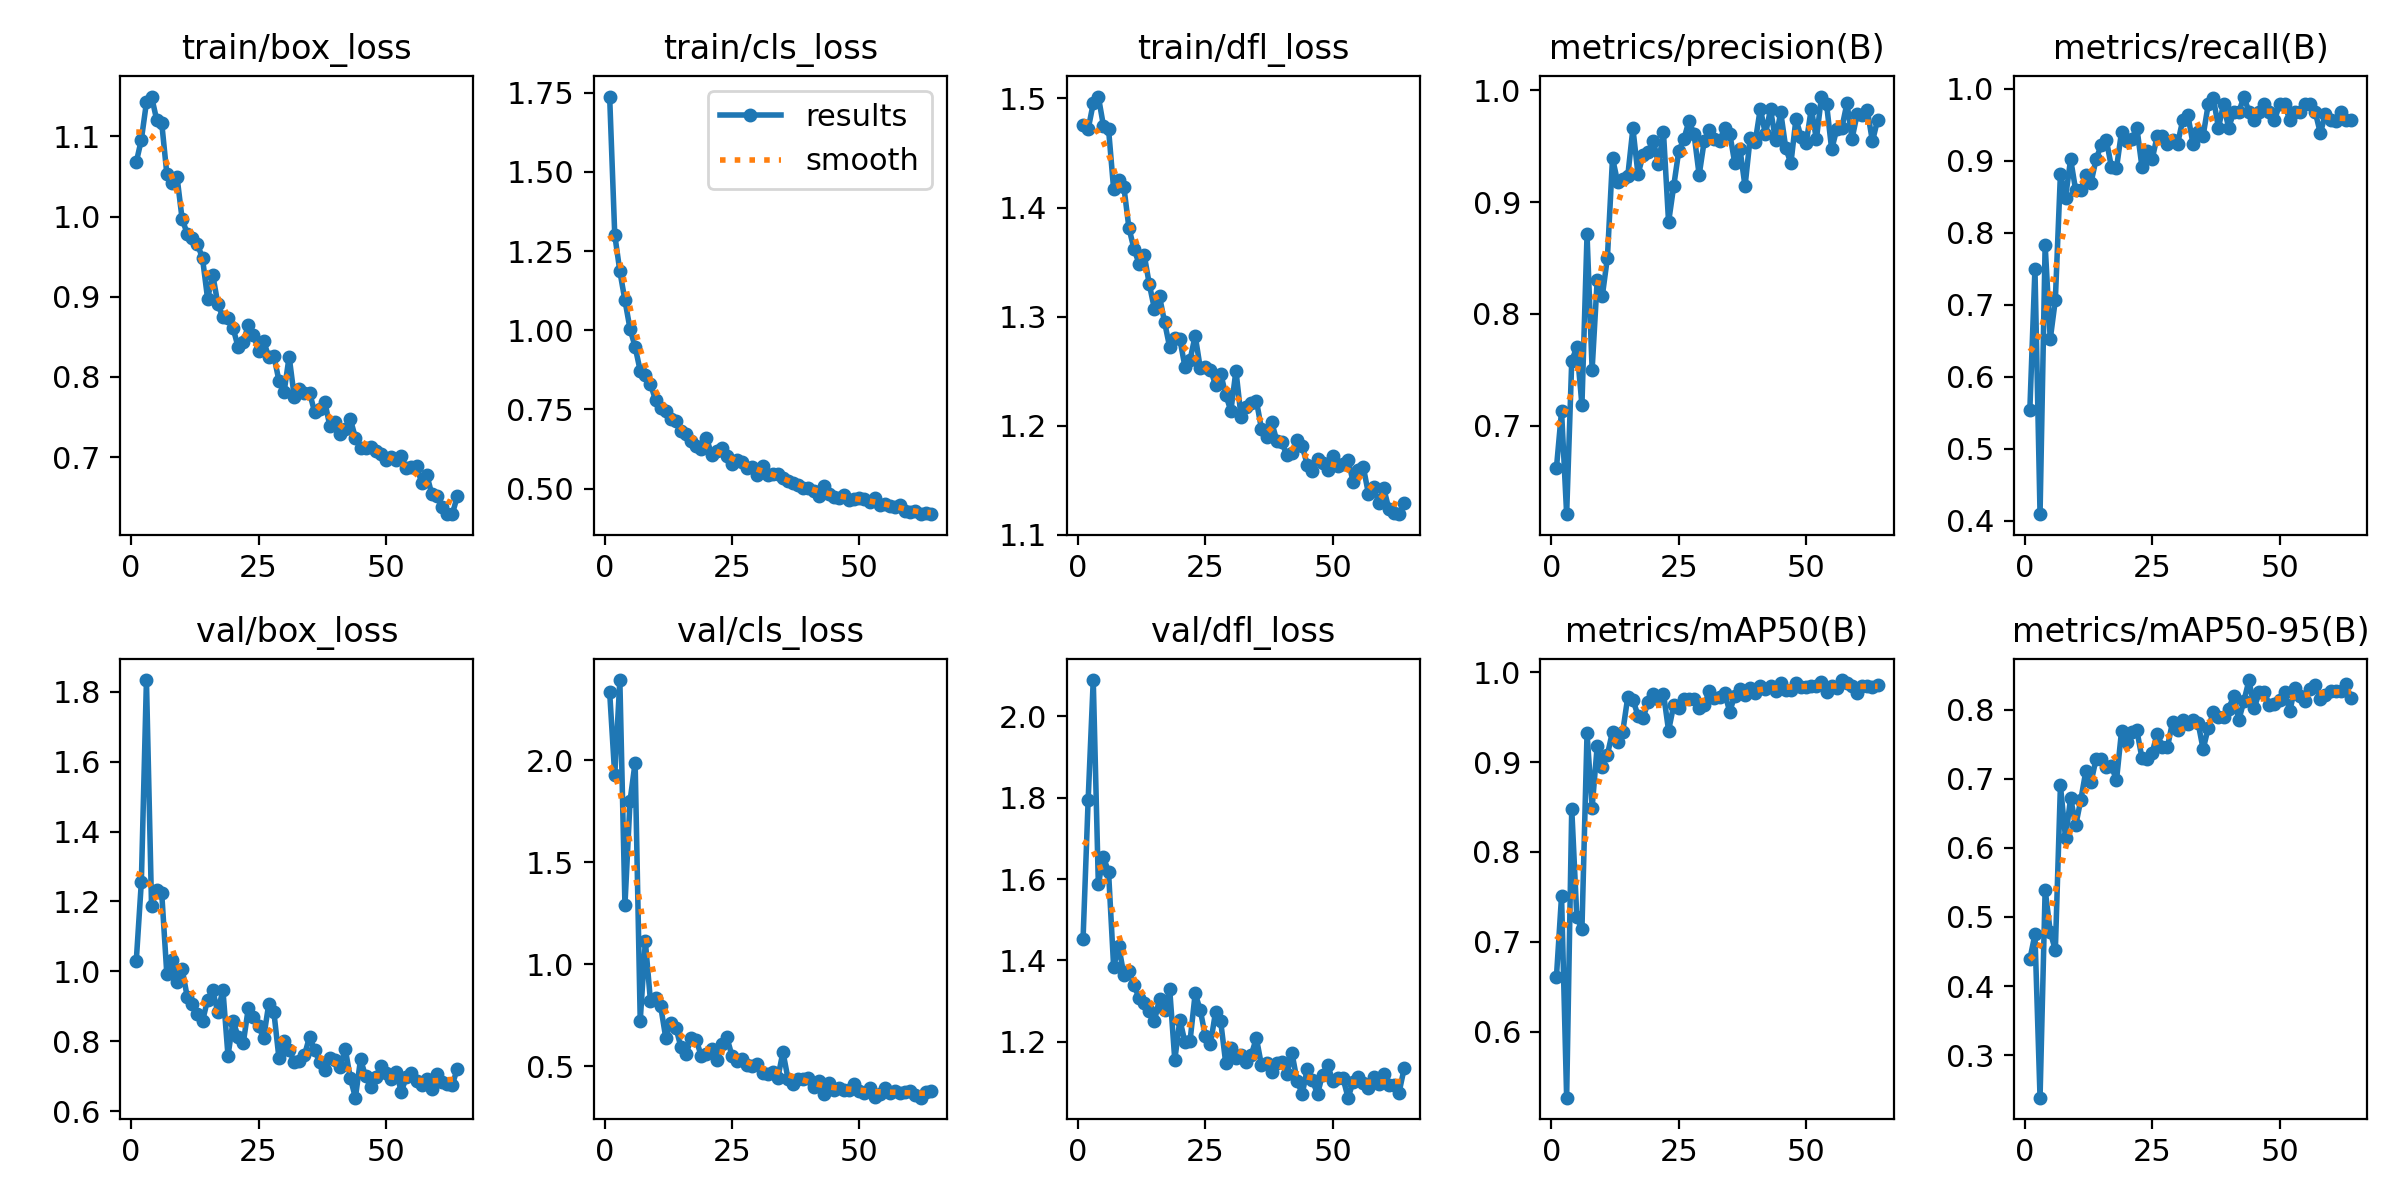


📊 Confusion Matrix:


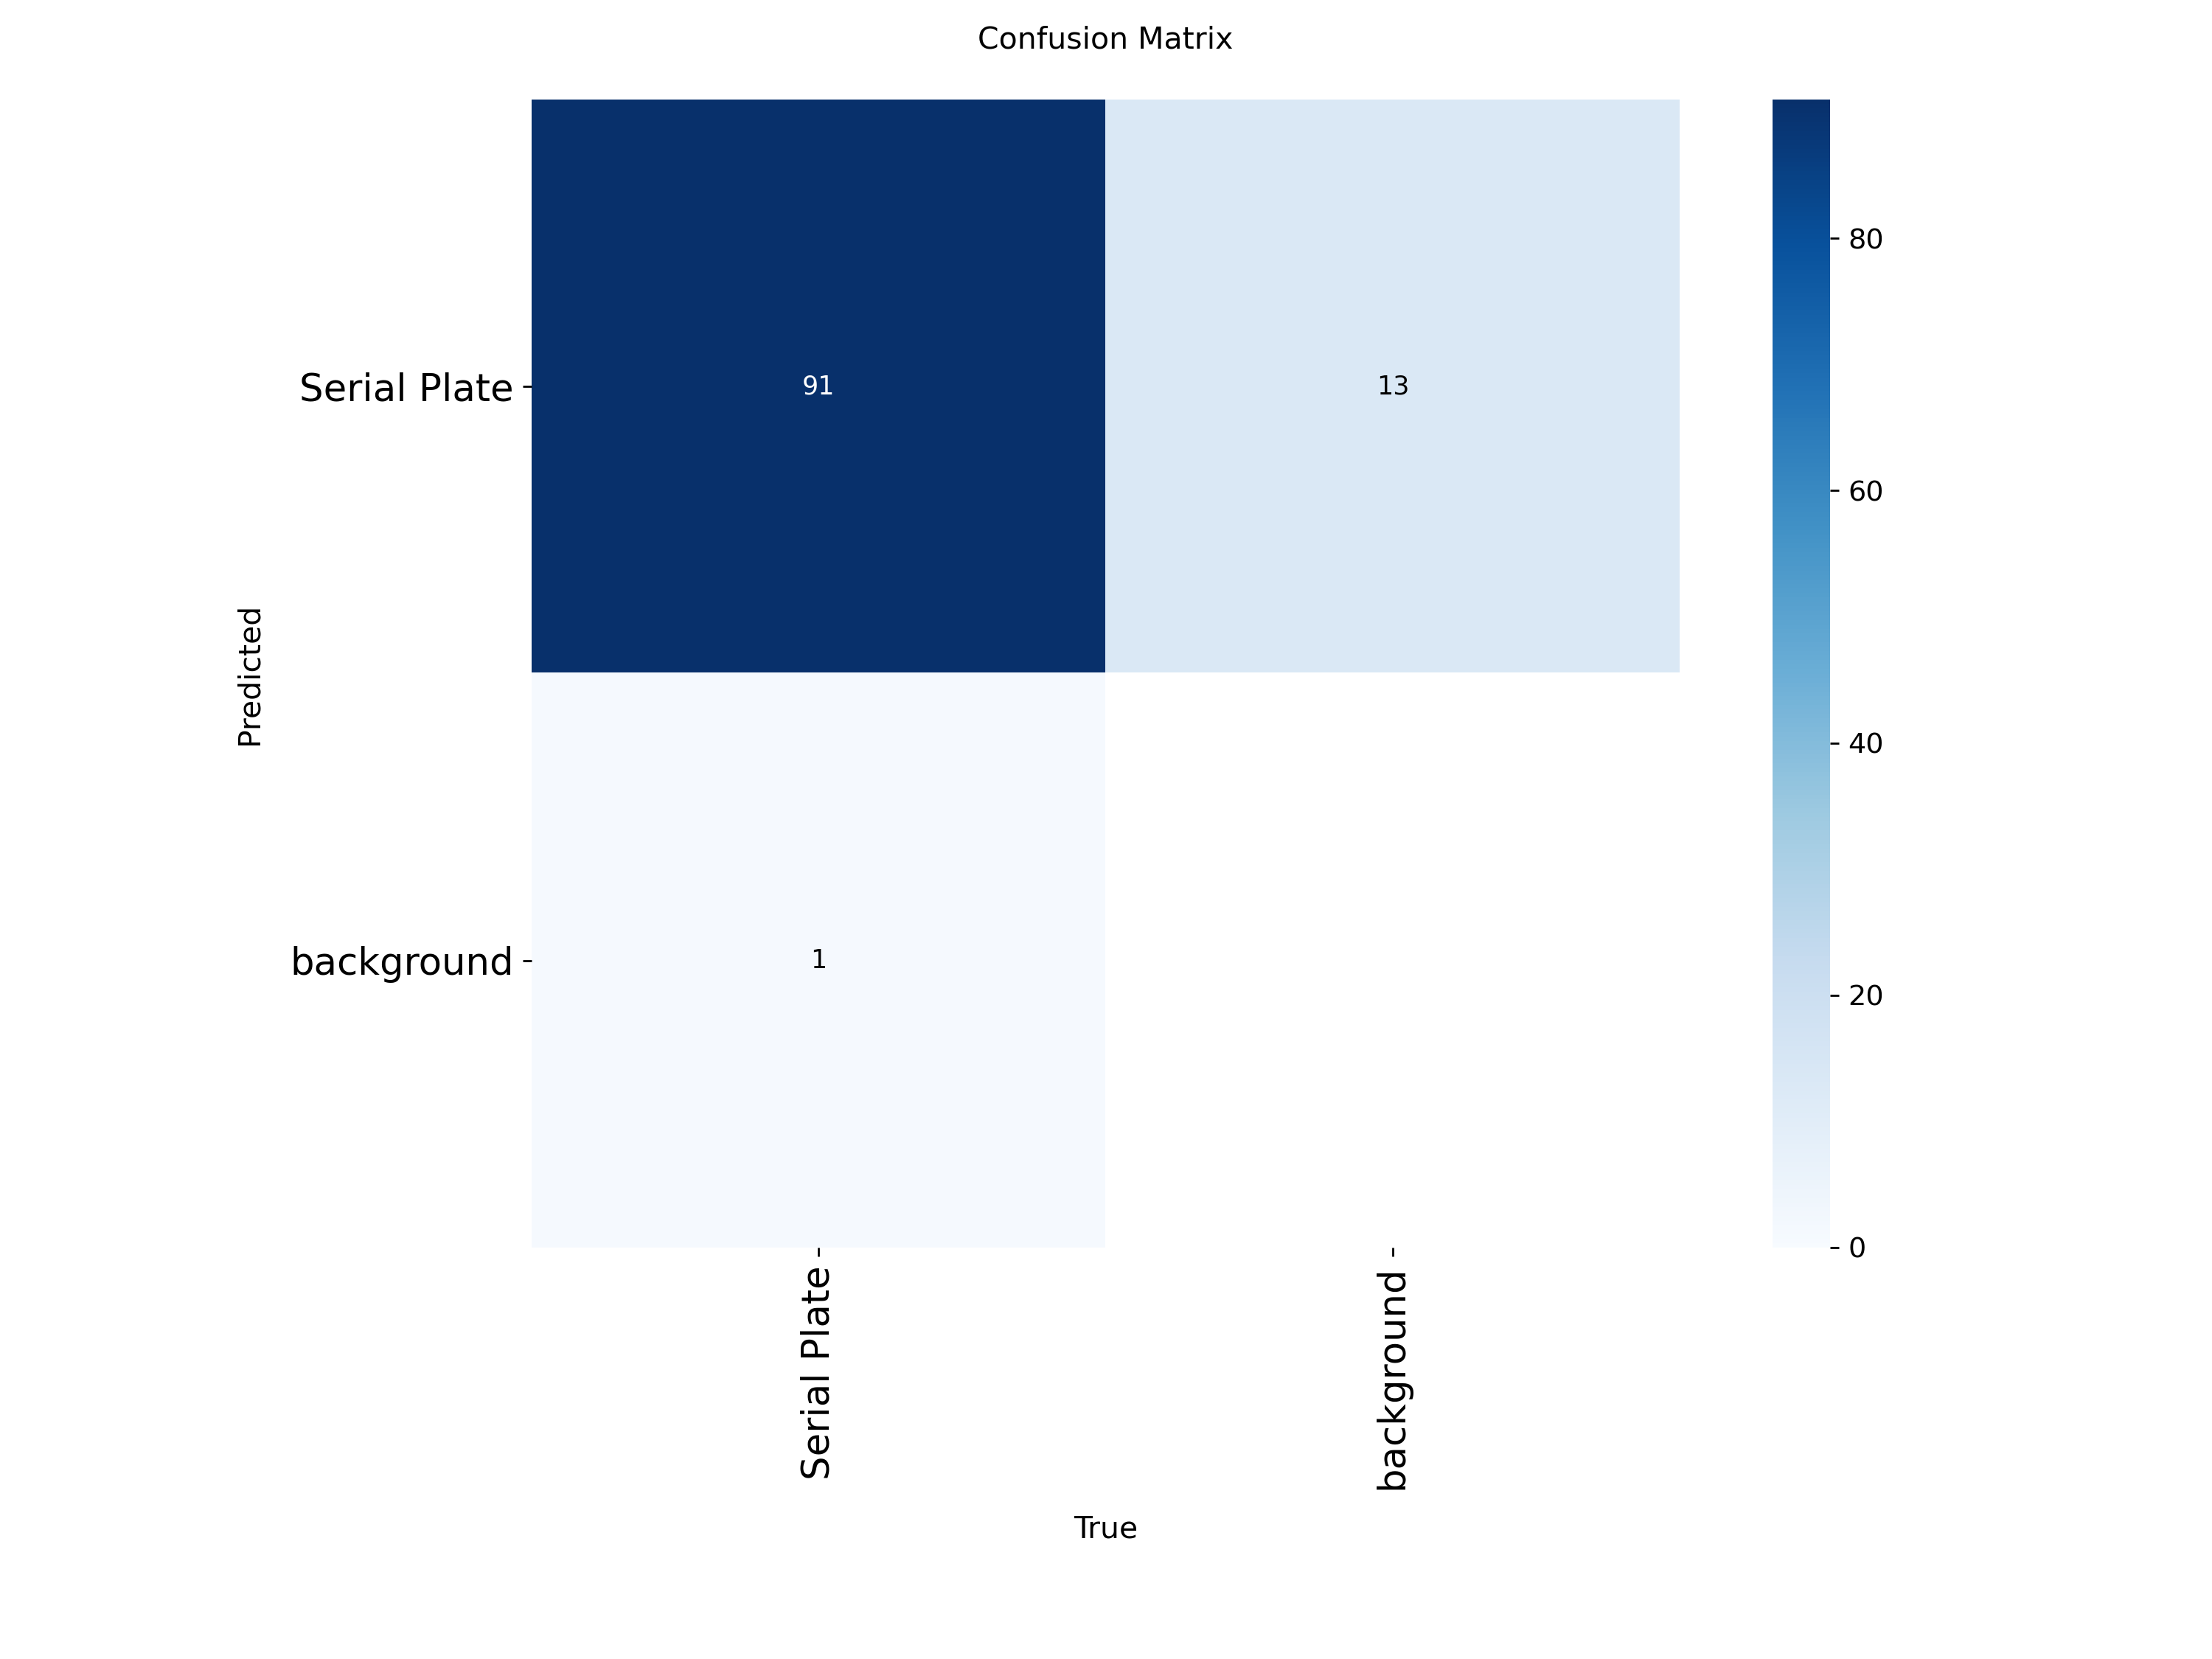


🔍 Predictions on Validation Set:


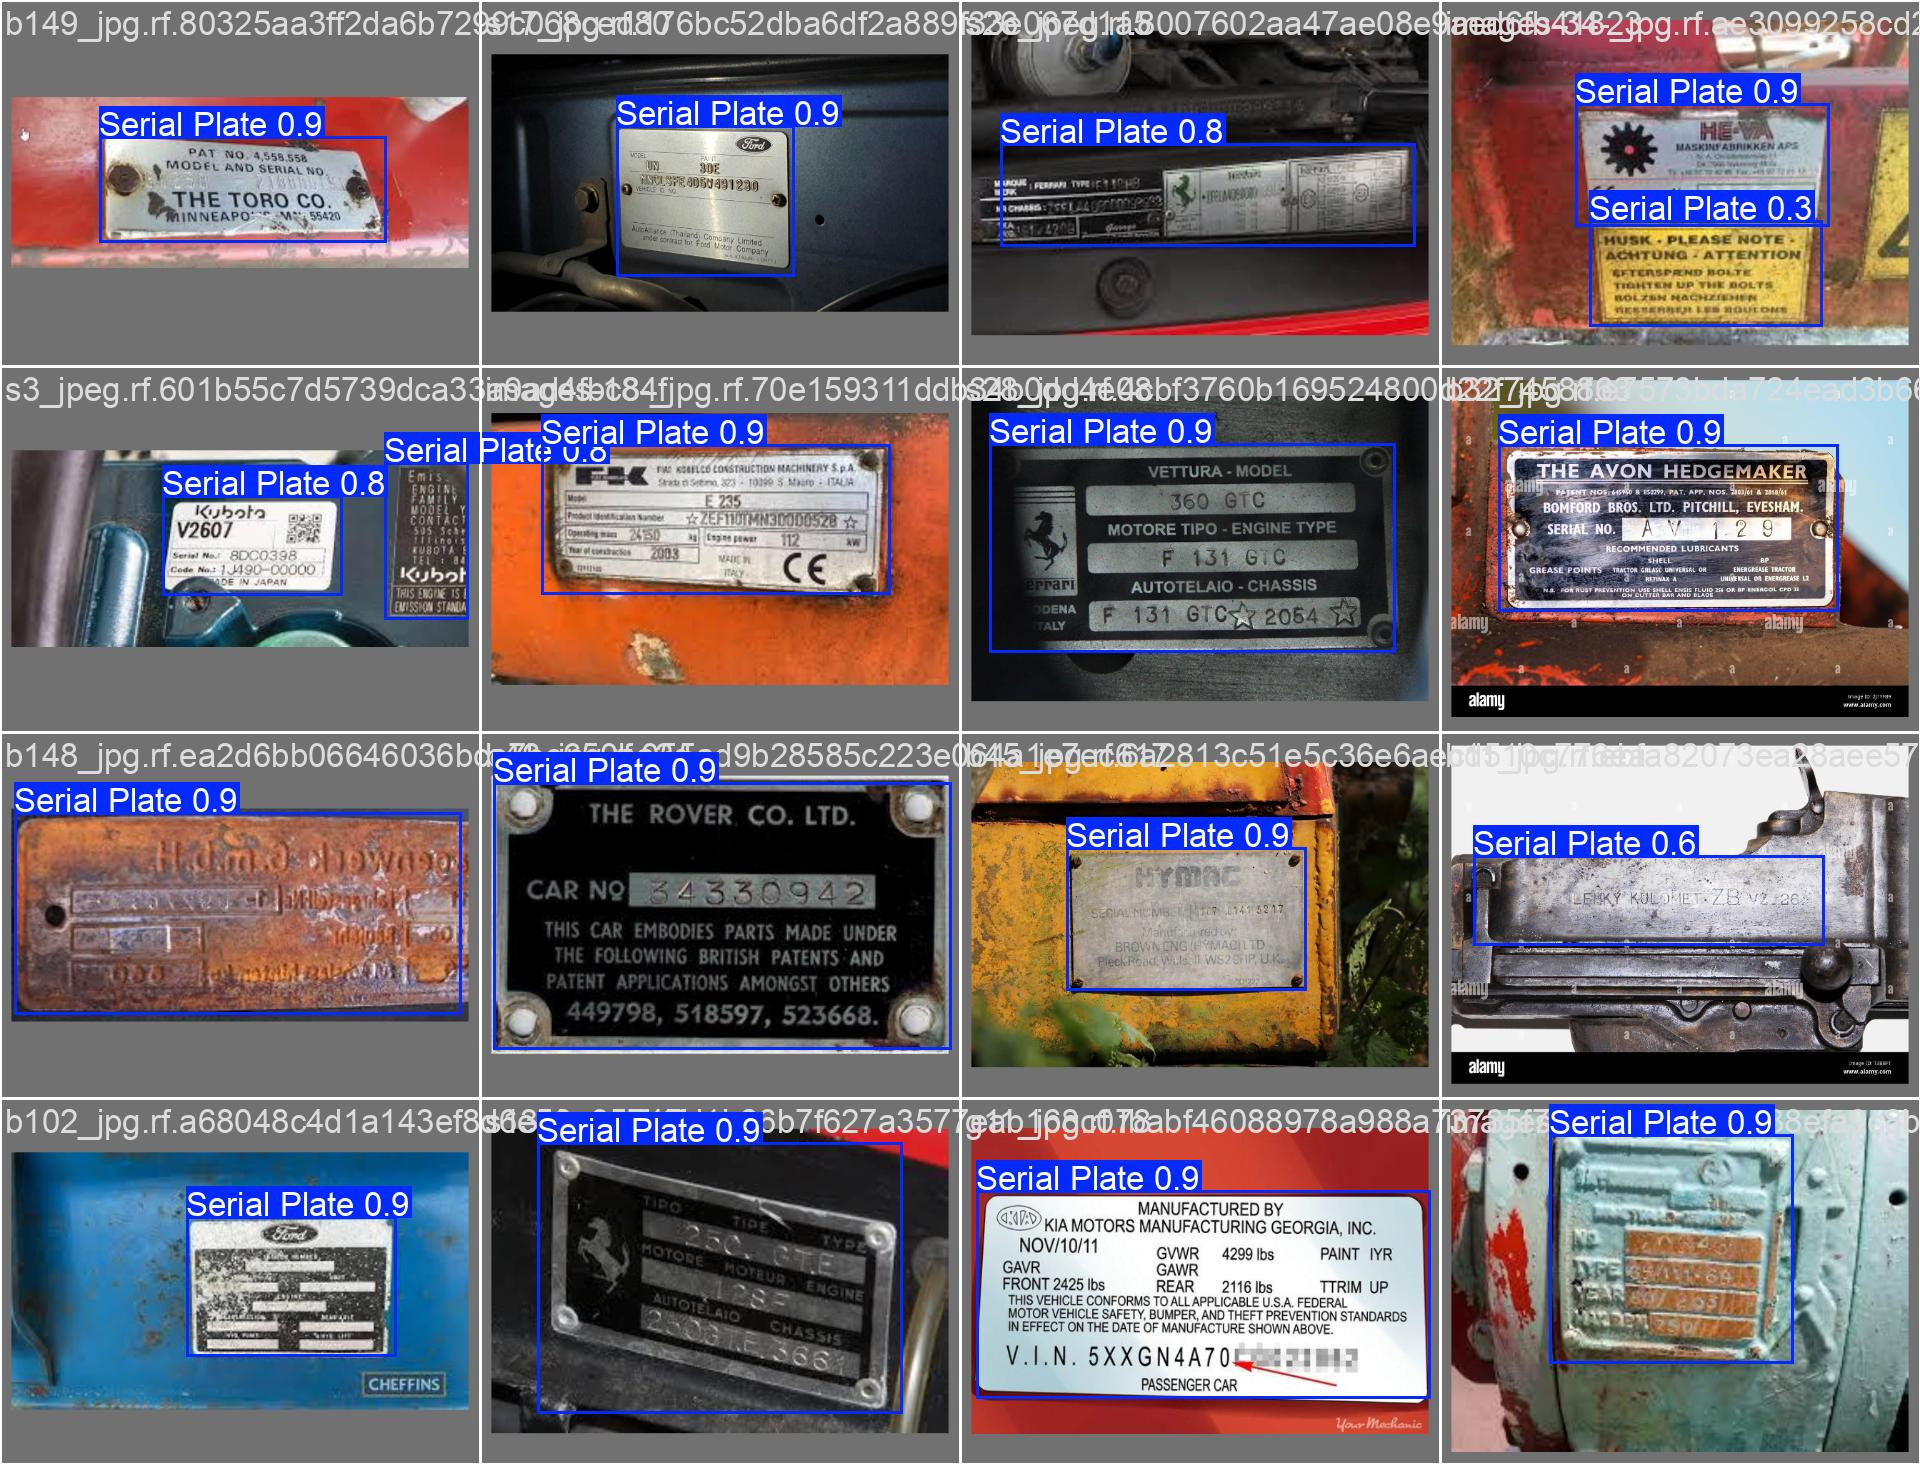

In [ ]:
from IPython.display import Image, display

# Training curves
print("📈 Training Results:")
display(Image('/content/runs/serial_plate/results.png'))

# Confusion matrix
print("\n📊 Confusion Matrix:")
display(Image('/content/runs/serial_plate/confusion_matrix.png'))

# Sample predictions
print("\n🔍 Predictions on Validation Set:")
display(Image('/content/runs/serial_plate/val_batch0_pred.jpg'))

In [ ]:
# Load best model
best_model = YOLO('/content/runs/serial_plate/weights/best.pt')

# Test
metrics = best_model.val(
    data='/content/OCRFYP.v1i.yolov8/data.yaml',
    split='test'
)

print("\n📊 Test Set Performance:")
print(f"   mAP50:     {metrics.box.map50:.1%}")
print(f"   mAP50-95:  {metrics.box.map:.1%}")
print(f"   Precision: {metrics.box.p[0]:.1%}")
print(f"   Recall:    {metrics.box.r[0]:.1%}")


Ultralytics 8.3.224 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 887.2±1126.2 MB/s, size: 105.8 KB)
val: Scanning /content/OCRFYP.v1i.yolov8/test/labels... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 1.5Kit/s 0.0s
val: New cache created: /content/OCRFYP.v1i.yolov8/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 50. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.9it/s 1.0s
                   all         47         50          1      0.921      0.974      0.782
Speed: 2.1ms preprocess, 6.8ms inference, 0.0ms loss, 0.

In [ ]:
from google.colab import files

# Download best model
files.download('/content/runs/serial_plate/weights/best.pt')

print("\n✅ Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloaded!
